# NB05: Groundwater vs Sediment Community Comparison

**Goal**: Compare planktonic (groundwater) vs attached (sediment) communities at the 5 wells with both sample types. Key question: does the groundwater community reflect the local sediment community, or does it represent a transported assemblage (i.e., the flowing plume)?

**Context**: The SSO sits downhill and southwest of a contamination source with high nitrate, low pH, and heavy metals. If groundwater carries a plume-associated community, GW samples across wells should be more similar to each other than to their paired sediment — the plume homogenizes the planktonic community.

**Wells with both materials**: L7, L9, M4, M6, U2 (5 of 9)  
**Temporal offset**: Sediment = Feb-Mar 2023, Groundwater = Sep 2024

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import braycurtis, squareform, pdist
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

OVERLAP_WELLS = ['SSO-L7', 'SSO-L9', 'SSO-M4', 'SSO-M6', 'SSO-U2']

# Load well-aggregated matrices
sed_phylum = pd.read_csv(DATA / 'community_matrix_sediment_phylum.csv', index_col=0)
gw_phylum = pd.read_csv(DATA / 'community_matrix_gw_phylum.csv', index_col=0)

# Align to overlapping wells and union of phyla
all_phyla = sorted(set(sed_phylum.columns) | set(gw_phylum.columns))
sed_ov = sed_phylum.reindex(index=OVERLAP_WELLS, columns=all_phyla, fill_value=0)
gw_ov = gw_phylum.reindex(index=OVERLAP_WELLS, columns=all_phyla, fill_value=0)

# Relative abundance
sed_rel = sed_ov.div(sed_ov.sum(axis=1), axis=0)
gw_rel = gw_ov.div(gw_ov.sum(axis=1), axis=0)

print(f"Overlap wells: {OVERLAP_WELLS}")
print(f"Phyla union: {len(all_phyla)}")
print(f"Sediment reads per well: {sed_ov.sum(axis=1).astype(int).to_dict()}")
print(f"Groundwater reads per well: {gw_ov.sum(axis=1).astype(int).to_dict()}")

Overlap wells: ['SSO-L7', 'SSO-L9', 'SSO-M4', 'SSO-M6', 'SSO-U2']
Phyla union: 88
Sediment reads per well: {'SSO-L7': 94122, 'SSO-L9': 96069, 'SSO-M4': 95875, 'SSO-M6': 95811, 'SSO-U2': 95707}
Groundwater reads per well: {'SSO-L7': 146159, 'SSO-L9': 142815, 'SSO-M4': 125906, 'SSO-M6': 156659, 'SSO-U2': 175862}


## 1. Paired Dissimilarity: GW vs Sediment at Each Well

For each well, compute BC dissimilarity between its GW and sediment communities. Then compare: are within-well (GW-sed) pairs more similar than between-well pairs?

In [2]:
# Within-well GW-sediment dissimilarity
within_well_bc = {}
for well in OVERLAP_WELLS:
    bc = braycurtis(sed_rel.loc[well].values, gw_rel.loc[well].values)
    within_well_bc[well] = bc
    
print("Within-well GW-Sediment Bray-Curtis dissimilarity:")
for w, bc in within_well_bc.items():
    print(f"  {w}: {bc:.3f}")

# GW-to-GW dissimilarity (across wells)
gw_bc_condensed = pdist(gw_rel.values, metric='braycurtis')
gw_bc_matrix = squareform(gw_bc_condensed)

# Sed-to-Sed dissimilarity (across wells)
sed_bc_condensed = pdist(sed_rel.values, metric='braycurtis')
sed_bc_matrix = squareform(sed_bc_condensed)

# Cross-material between-well: GW(well_i) vs Sed(well_j) for i!=j
cross_between = []
for i, w1 in enumerate(OVERLAP_WELLS):
    for j, w2 in enumerate(OVERLAP_WELLS):
        if i != j:
            bc = braycurtis(gw_rel.loc[w1].values, sed_rel.loc[w2].values)
            cross_between.append(bc)

print(f"\nWithin-well GW-Sed:       median = {np.median(list(within_well_bc.values())):.3f} (n={len(within_well_bc)})")
print(f"Between-well GW-GW:       median = {np.median(gw_bc_condensed):.3f} (n={len(gw_bc_condensed)})")
print(f"Between-well Sed-Sed:     median = {np.median(sed_bc_condensed):.3f} (n={len(sed_bc_condensed)})")
print(f"Between-well GW-Sed:      median = {np.median(cross_between):.3f} (n={len(cross_between)})")

# Is GW more homogeneous than sediment? (plume homogenization hypothesis)
stat, p = mannwhitneyu(gw_bc_condensed, sed_bc_condensed, alternative='less')
print(f"\nMann-Whitney (GW < Sed dissimilarity): U={stat:.0f}, p={p:.4f}")
if p < 0.05:
    print("→ GW communities are significantly MORE similar to each other than sediment")
    print("  Consistent with plume-transported homogenization")
else:
    print("→ No significant difference in within-material homogeneity")

Within-well GW-Sediment Bray-Curtis dissimilarity:
  SSO-L7: 0.450
  SSO-L9: 0.369
  SSO-M4: 0.364
  SSO-M6: 0.427
  SSO-U2: 0.424

Within-well GW-Sed:       median = 0.424 (n=5)
Between-well GW-GW:       median = 0.298 (n=10)
Between-well Sed-Sed:     median = 0.256 (n=10)
Between-well GW-Sed:      median = 0.416 (n=20)

Mann-Whitney (GW < Sed dissimilarity): U=59, p=0.7637
→ No significant difference in within-material homogeneity


## 2. Phylum Composition: GW vs Sediment Side-by-Side

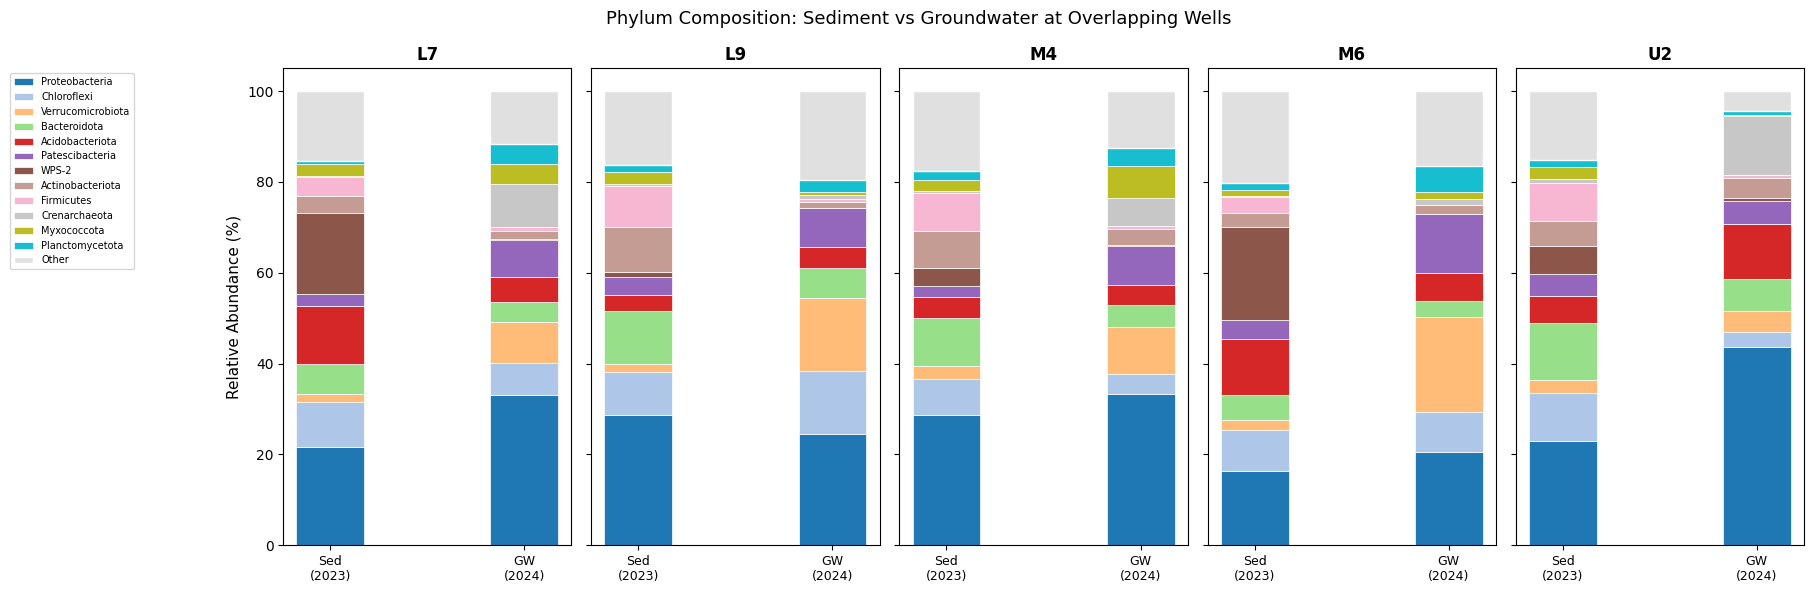

Saved: figures/gw_vs_sediment_phylum.png


In [3]:
# Side-by-side phylum composition: sediment vs groundwater
top_phyla = (pd.concat([sed_rel[OVERLAP_WELLS[0]:OVERLAP_WELLS[-1]].sum(),
                        gw_rel[OVERLAP_WELLS[0]:OVERLAP_WELLS[-1]].sum()])
             .groupby(level=0).sum()
             .sort_values(ascending=False).head(12).index.tolist())

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)
cmap = plt.cm.tab20

for idx, well in enumerate(OVERLAP_WELLS):
    ax = axes[idx]
    # Sediment bar (left)
    bottom_s = 0
    bottom_g = 0
    for i, phylum in enumerate(top_phyla):
        s_val = sed_rel.loc[well, phylum] * 100 if phylum in sed_rel.columns else 0
        g_val = gw_rel.loc[well, phylum] * 100 if phylum in gw_rel.columns else 0
        color = cmap(i / len(top_phyla))
        ax.bar(0, s_val, bottom=bottom_s, color=color, width=0.35, edgecolor='white', linewidth=0.5)
        ax.bar(1, g_val, bottom=bottom_g, color=color, width=0.35, edgecolor='white', linewidth=0.5,
               label=phylum if idx == 0 else None)
        bottom_s += s_val
        bottom_g += g_val
    
    # Other
    ax.bar(0, 100-bottom_s, bottom=bottom_s, color='#E0E0E0', width=0.35, edgecolor='white')
    ax.bar(1, 100-bottom_g, bottom=bottom_g, color='#E0E0E0', width=0.35, edgecolor='white',
           label='Other' if idx == 0 else None)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sed\n(2023)', 'GW\n(2024)'], fontsize=9)
    ax.set_title(well.replace('SSO-', ''), fontsize=12, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Relative Abundance (%)', fontsize=11)

axes[0].legend(bbox_to_anchor=(-0.5, 1), loc='upper right', fontsize=7)
plt.suptitle('Phylum Composition: Sediment vs Groundwater at Overlapping Wells', fontsize=13)
plt.tight_layout()
plt.savefig(FIG / 'gw_vs_sediment_phylum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/gw_vs_sediment_phylum.png")

## 3. GW Genus-Level: Plume Indicator Taxa

Check whether known ORR contaminant-plume indicator genera (Rhodanobacter, Anaeromyxobacter, etc.) are enriched in groundwater relative to sediment — this would indicate the GW carries a plume-associated community.

In [4]:
# Load raw data for genus-level comparison
sed_raw = pd.read_parquet(DATA / 'sso_sediment_asv.parquet')
gw_raw = pd.read_parquet(DATA / 'sso_groundwater_asv.parquet')

# Key ORR plume-indicator genera
PLUME_GENERA = ['Rhodanobacter', 'Anaeromyxobacter', 'Geobacter', 'Desulfovibrio',
                'Thiobacillus', 'Arcobacter', 'Sideroxydans', 'Gallionella',
                'Pseudomonas', 'Herbaspirillum', 'Sphingomonas', 'Massilia',
                'Candidatus Methanoperedens', 'Comamonas', 'Methyloversatilis']

# Compute relative abundance for each indicator genus in each material+well
results = []
for well in OVERLAP_WELLS:
    sed_w = sed_raw[sed_raw['location'] == well]
    gw_w = gw_raw[gw_raw['location'] == well]
    sed_total = sed_w['abundance'].sum()
    gw_total = gw_w['abundance'].sum()
    
    for genus in PLUME_GENERA:
        sed_abund = sed_w[sed_w['genus'] == genus]['abundance'].sum()
        gw_abund = gw_w[gw_w['genus'] == genus]['abundance'].sum()
        results.append({
            'well': well.replace('SSO-', ''),
            'genus': genus,
            'sed_pct': sed_abund / sed_total * 100 if sed_total > 0 else 0,
            'gw_pct': gw_abund / gw_total * 100 if gw_total > 0 else 0,
        })

plume_df = pd.DataFrame(results)
plume_df['gw_sed_ratio'] = (plume_df['gw_pct'] + 0.001) / (plume_df['sed_pct'] + 0.001)

# Summary: mean across wells
plume_summary = plume_df.groupby('genus').agg(
    mean_sed=('sed_pct', 'mean'),
    mean_gw=('gw_pct', 'mean')
).sort_values('mean_gw', ascending=False)
plume_summary['enrichment'] = plume_summary['mean_gw'] / (plume_summary['mean_sed'] + 0.001)

print("Plume indicator genera: Sediment vs Groundwater (mean % across overlap wells)")
print(f"{'Genus':<30} {'Sed%':>7} {'GW%':>7} {'GW/Sed':>8}")
print("-" * 55)
for genus, r in plume_summary.iterrows():
    arrow = "▲GW" if r['enrichment'] > 2 else ("▼GW" if r['enrichment'] < 0.5 else "  ~")
    print(f"{genus:<30} {r['mean_sed']:>7.2f} {r['mean_gw']:>7.2f} {r['enrichment']:>7.1f}x {arrow}")

Plume indicator genera: Sediment vs Groundwater (mean % across overlap wells)
Genus                             Sed%     GW%   GW/Sed
-------------------------------------------------------
Rhodanobacter                     1.23    3.62     2.9x ▲GW
Pseudomonas                       0.40    0.45     1.1x   ~
Sphingomonas                      0.62    0.25     0.4x ▼GW
Gallionella                       0.01    0.14     8.9x ▲GW
Massilia                          0.32    0.09     0.3x ▼GW
Sideroxydans                      0.01    0.06     7.0x ▲GW
Anaeromyxobacter                  1.24    0.03     0.0x ▼GW
Thiobacillus                      0.29    0.03     0.1x ▼GW
Herbaspirillum                    0.08    0.01     0.2x ▼GW
Geobacter                         0.00    0.01     5.5x ▲GW
Methyloversatilis                 0.43    0.00     0.0x ▼GW
Desulfovibrio                     0.04    0.00     0.0x ▼GW
Comamonas                         0.09    0.00     0.0x ▼GW
Arcobacter                    

## 4. Summary

In [5]:
print("=" * 60)
print("NB05 GROUNDWATER vs SEDIMENT SUMMARY")
print("=" * 60)

ww_vals = list(within_well_bc.values())
print(f"\n1. WITHIN-WELL GW-SEDIMENT DISSIMILARITY")
print(f"   Median: {np.median(ww_vals):.3f}  Range: {min(ww_vals):.3f} - {max(ww_vals):.3f}")
for w, bc in within_well_bc.items():
    print(f"   {w}: {bc:.3f}")

print(f"\n2. MATERIAL HOMOGENEITY")
print(f"   GW-GW between wells:   median BC = {np.median(gw_bc_condensed):.3f}")
print(f"   Sed-Sed between wells: median BC = {np.median(sed_bc_condensed):.3f}")
if np.median(gw_bc_condensed) < np.median(sed_bc_condensed):
    print(f"   → GW is more homogeneous across wells than sediment")
else:
    print(f"   → Sediment is more homogeneous across wells than GW")

print(f"\n3. PLUME INDICATOR ENRICHMENT IN GW")
enriched = plume_summary[plume_summary['enrichment'] > 2]
depleted = plume_summary[plume_summary['enrichment'] < 0.5]
if len(enriched) > 0:
    print(f"   GW-enriched (>2x): {', '.join(enriched.index)}")
if len(depleted) > 0:
    print(f"   GW-depleted (<0.5x): {', '.join(depleted.index)}")

print(f"\nFiles saved:")
print(f"  figures/gw_vs_sediment_phylum.png")

NB05 GROUNDWATER vs SEDIMENT SUMMARY

1. WITHIN-WELL GW-SEDIMENT DISSIMILARITY
   Median: 0.424  Range: 0.364 - 0.450
   SSO-L7: 0.450
   SSO-L9: 0.369
   SSO-M4: 0.364
   SSO-M6: 0.427
   SSO-U2: 0.424

2. MATERIAL HOMOGENEITY
   GW-GW between wells:   median BC = 0.298
   Sed-Sed between wells: median BC = 0.256
   → Sediment is more homogeneous across wells than GW

3. PLUME INDICATOR ENRICHMENT IN GW
   GW-enriched (>2x): Rhodanobacter, Gallionella, Sideroxydans, Geobacter
   GW-depleted (<0.5x): Sphingomonas, Massilia, Anaeromyxobacter, Thiobacillus, Herbaspirillum, Methyloversatilis, Desulfovibrio, Comamonas, Arcobacter, Candidatus Methanoperedens

Files saved:
  figures/gw_vs_sediment_phylum.png
